#Deep Learning Case Study

###Importing required libraries


In [1]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D, SeparableConv2D

from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,Callback,ReduceLROnPlateau

from tensorflow.keras.applications import VGG16


2026-05-26 02:57:42.912423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779764263.312220      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779764263.426364      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779764264.421184      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779764264.421230      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779764264.421234      57 computation_placer.cc:177] computation placer alr

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


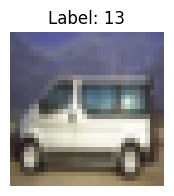

Image Shape: (32, 32, 3)
     0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23   24   25   26   27   28   29   30   31
0    78   86   91   87   85   86   84   85   88   89   89   90   93   96  103  109  111  111  105  100  101  104  104  102   99   99  101  102   98   92   89   84
1    77   80   91   93   87   87   88   89   91   92   93   97  103  107  109  111  113  116  116  112  110  109  107  106  105  105  106  106  100   94   93   92
2    85   78   81   86   93   94   92   93   95   96   99  107  112  113  110  110  110  110  115  115  112  109  107  107  106  106  103  101  104  102  102   97
3    87   82   82   83   95  103  102  101  103  106  109  111  109  111  112  108  106  104  107  110  112  111  109  107  108  104  100   98  102  101   98   92
4    82   79   81   82   88   94   99  111  114  112  110  103  101  107  109  105  104  105  109  111  111  114  109  103  106  102  100   97   99  100   94   

In [2]:
# Loading CIFAR-100 dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# Selecting image index
i = 786

# Displaying the image
plt.figure(figsize=(2,2))
plt.imshow(X_train[i])
plt.title(f"Label: {y_train[i][0]}")
plt.axis('off')
plt.show()

# Printing image shape
print("Image Shape:", X_train[i].shape)

# Converting only one channel (Red channel) into DataFrame
data = pd.DataFrame(X_train[i][:,:,0])

# Printing DataFrame
print(data.to_string())

###Normalize Images

In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

###One-Hot Encoding

In [4]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

##Part 1 — Custom CNN Model

###Build Custom CNN Model

In [5]:
cnn_model = Sequential()

cnn_model.add(Input(shape=(32,32,3)))


cnn_model.add(Conv2D(
    64,
    (3,3),
    padding='same',
    activation='relu',
    kernel_initializer='he_normal'
))

cnn_model.add(BatchNormalization())

cnn_model.add(Conv2D(
    64,
    (3,3),
    padding='same',
    activation='relu',
    kernel_initializer='he_normal'
))

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Dropout(0.2))

cnn_model.add(SeparableConv2D(
    128,
    (3,3),
    padding='same',
    activation='relu'
))

cnn_model.add(BatchNormalization())

cnn_model.add(SeparableConv2D(
    128,
    (3,3),
    padding='same',
    activation='relu'
))

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Dropout(0.3))


cnn_model.add(SeparableConv2D(
    256,
    (3,3),
    padding='same',
    activation='relu'
))

cnn_model.add(BatchNormalization())

cnn_model.add(SeparableConv2D(
    256,
    (3,3),
    padding='same',
    activation='relu'
))

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Dropout(0.3))


cnn_model.add(SeparableConv2D(
    512,
    (3,3),
    padding='same',
    activation='relu'
))

cnn_model.add(BatchNormalization())

cnn_model.add(Dropout(0.4))

# GLOBAL AVERAGE POOLING


cnn_model.add(GlobalAveragePooling2D())

cnn_model.add(Dense(
    1024,
    activation='relu',
    kernel_initializer='he_normal'
))

cnn_model.add(BatchNormalization())

cnn_model.add(Dropout(0.5))


cnn_model.add(Dense(
    100,
    activation='softmax'
))

I0000 00:00:1779764308.257044      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779764308.263061      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


###Compile Custom CNN

In [6]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

###Callbacks

In [7]:
# Callbacks
custom_callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        'best_custom_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]


###Train Custom CNN

In [8]:
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=40,
    validation_data=(X_test, y_test),
    batch_size=64,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/40


I0000 00:00:1779764318.057423     129 service.cc:152] XLA service 0x7b84fc00a3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779764318.057479     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779764318.057485     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779764319.270095     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779764333.726016     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0652 - loss: 4.7763
Epoch 1: val_accuracy improved from -inf to 0.16380, saving model to best_custom_cnn.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.0652 - loss: 4.7758 - val_accuracy: 0.1638 - val_loss: 3.7048 - learning_rate: 0.0010
Epoch 2/40
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1868 - loss: 3.5336
Epoch 2: val_accuracy improved from 0.16380 to 0.28140, saving model to best_custom_cnn.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1869 - loss: 3.5333 - val_accuracy: 0.2814 - val_loss: 2.8288 - learning_rate: 0.0010
Epoch 3/40
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2715 - loss: 3.0198
Epoch 3: val_accuracy improved from 0.28140 to 0.34870, saving model to best_custom_cnn.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2716 - loss: 3.0193 - val_accuracy: 0.3487 - val_loss: 2.6582 - learning_rate: 0.0010
Epoch 4/40
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s

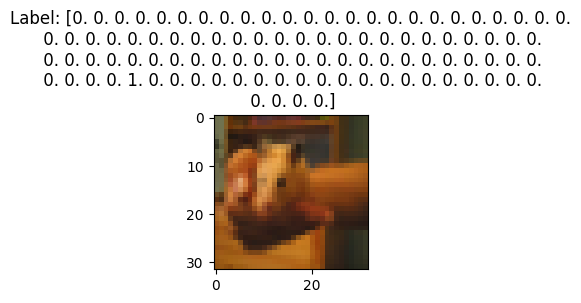

In [9]:
index = 3245
plt.figure(figsize=(2,2))
plt.imshow(X_test[index],cmap='gray')
plt.title(f"Label: {y_train[index]}")
plt.show()

###Plot Custom CNN Accuracy

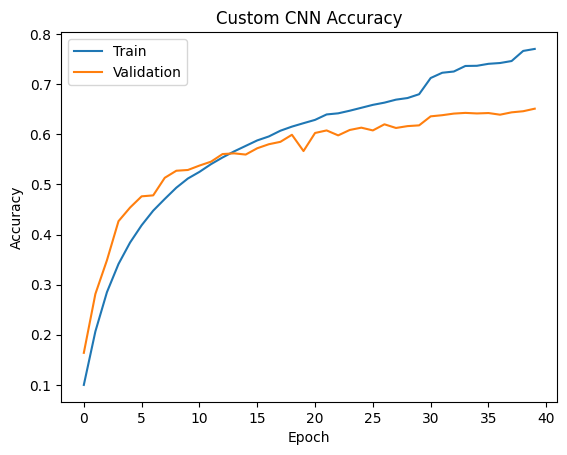

In [10]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

###Plot Custom CNN Loss

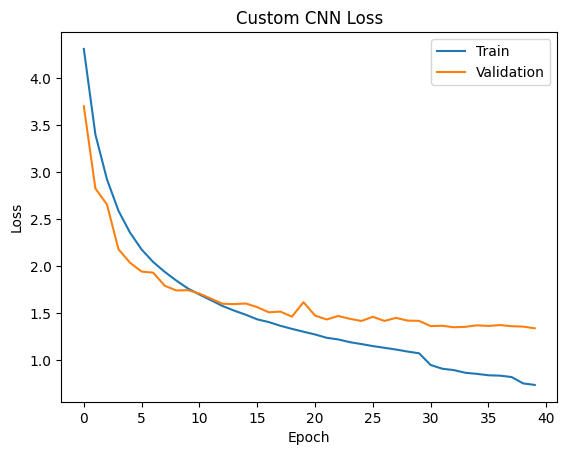

In [11]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

###Evaluate Custom CNN

In [12]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test)

print("Custom CNN Accuracy:", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6553 - loss: 1.3575
Custom CNN Accuracy: 0.6513000130653381


##Part 2 — Predefined VGG16 Architecture

###Load dataset

In [13]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

###Resize image

In [14]:
x_train = tf.image.resize(x_train, (64, 64))
x_test = tf.image.resize(x_test, (64, 64))


###Adding VGG16 preprocessing

In [15]:
from tensorflow.keras.applications.vgg16 import preprocess_input

x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [16]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


###Load VGG16 Base Model

In [18]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Freeze VGG16 Layers

In [19]:
for layer in base_model.layers[:-2]:
    layer.trainable = False

for layer in base_model.layers[-2:]:
    layer.trainable = True


###Build VGG16 Model

In [20]:

from tensorflow.keras.regularizers import l2
model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu',kernel_regularizer=l2(0.001)))
model.add(Dropout(0.6))
model.add(Dense(100, activation='softmax'))

In [21]:
vgg_callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        'best_vgg16.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]


###Compile VGG16 Model

In [22]:
from tensorflow.keras.optimizers import Adam


In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 2,359,808 (9.00 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

###Train VGG16 Model

In [25]:
history_vgg = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=vgg_callbacks
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0567 - loss: 6.4870
Epoch 1: val_accuracy improved from -inf to 0.35120, saving model to best_vgg16.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.0567 - loss: 6.4854 - val_accuracy: 0.3512 - val_loss: 3.0330 - learning_rate: 1.0000e-04
Epoch 2/20
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2765 - loss: 3.3471
Epoch 2: val_accuracy improved from 0.35120 to 0.46520, saving model to best_vgg16.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.2765 - loss: 3.3469 - val_accuracy: 0.4652 - val_loss: 2.3419 - learning_rate: 1.0000e-04
Epoch 3/20
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3850 - loss: 2.6671
Epoch 3: val_accuracy improved from 0.46520 to 0.50710, saving model to best_vgg16.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.3850 - loss: 2.6671 - val_accuracy: 0.5071 - val_loss: 2.0101 - learning_rate: 1.0000e-04
Epoch 4/20
3123/3125 ━━━━━━━━━━━━

In [26]:
vgg_loss, vgg_accuracy = model.evaluate(X_test, y_test)

print("VGG16 Accuracy:", vgg_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0113 - loss: 4.7700
VGG16 Accuracy: 0.010700000450015068


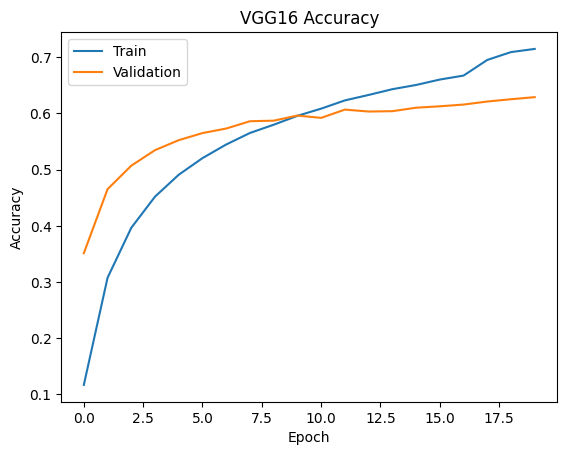

In [27]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

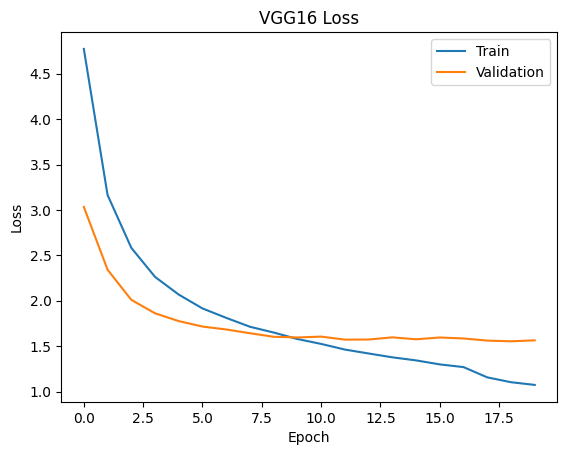

In [28]:
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])

plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [29]:
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16'],
    'Accuracy': [cnn_accuracy, vgg_accuracy]
})

print(comparison)

        Model  Accuracy
0  Custom CNN    0.6513
1       VGG16    0.0107


In [30]:
print("Custom CNN Accuracy:", cnn_accuracy)
print("VGG16 Accuracy:", vgg_accuracy)

Custom CNN Accuracy: 0.6513000130653381
VGG16 Accuracy: 0.010700000450015068


###Test Accuracy in Table

In [31]:
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16'],
    'Test Accuracy': [cnn_accuracy, vgg_accuracy],
    'Test Loss': [cnn_loss, vgg_loss]
})

comparison

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.6513,1.338708
1,VGG16,0.0107,4.771598


###Plot Accuracy Comparison Graph

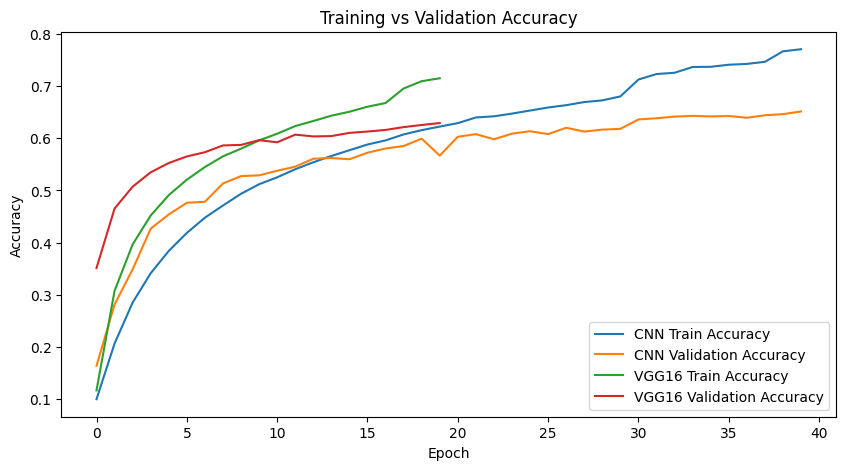

In [32]:
plt.figure(figsize=(10,5))

# Custom CNN
plt.plot(
    history_cnn.history['accuracy'],
    label='CNN Train Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

# VGG16
plt.plot(
    history_vgg.history['accuracy'],
    label='VGG16 Train Accuracy'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='VGG16 Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

###Plot Loss Comparison Graph

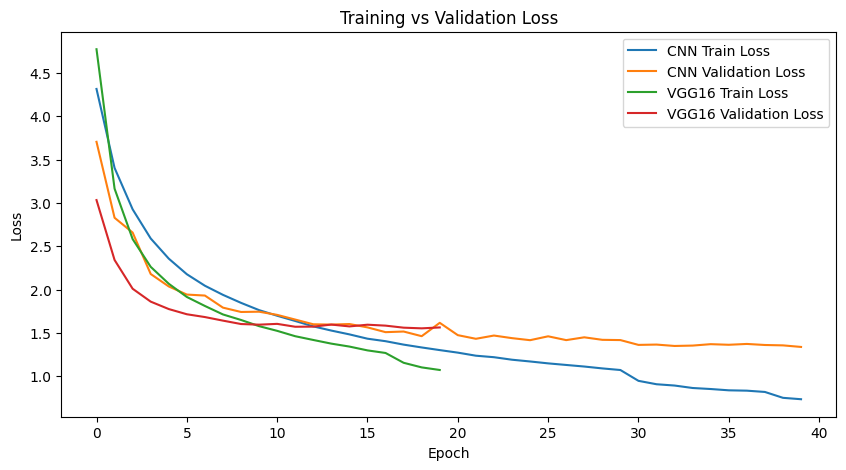

In [33]:
plt.figure(figsize=(10,5))

# Custom CNN
plt.plot(
    history_cnn.history['loss'],
    label='CNN Train Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='CNN Validation Loss'
)

# VGG16
plt.plot(
    history_vgg.history['loss'],
    label='VGG16 Train Loss'
)

plt.plot(
    history_vgg.history['val_loss'],
    label='VGG16 Validation Loss'
)

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()